In [53]:
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector 
import matplotlib.pyplot as plt
from qiskit.visualization import plot_state_qsphere
from IPython.display import display

### Quantum Teleportation & Hardware-Compatible Verification

1. The Objective :

Quantum Teleportation is a protocol that allows the transfer of an unknown quantum state, $|\psi\rangle$, from a sender (Alice) to a receiver (Bob) without physically moving the qubit itself. This is achieved by consuming quantum entanglement and transmitting two bits of classical information.

2. The Entangled Bridge:
   
Before communication begins, Alice and Bob must share a maximally entangled Bell state. This is created by applying a Hadamard ($H$) and a CNOT ($CX$) gate to two qubits ($q_1$ and $q_2$). Alice retains $q_1$, and Bob takes $q_2$.

3. Alice's Protocol & Measurement: 

Alice wants to teleport a payload qubit ($q_0$) initialized in the state $|\psi\rangle$. 
* She entangles her payload with her half of the bridge using a CNOT gate (target: $q_1$), followed by a Hadamard gate on $q_0$.
* She then measures both of her qubits in the computational basis. This measurement destroys the quantum state on her end and yields two classical bits. She transmits these bits to Bob via a standard classical channel.

4. Bob's Reconstruction :

Due to the initial entanglement, Alice's measurement instantly collapses Bob's qubit ($q_2$) into a state that is directly related to $|\psi\rangle$, but encrypted by Pauli operations. Using Alice's classical bits as a key, Bob applies classical conditional logic:
* If Alice's $q_1$ measured as 1, Bob applies an $X$ gate (bit flip).
* If Alice's $q_0$ measured as 1, Bob applies a $Z$ gate (phase flip).
Once applied, Bob's qubit transforms into the exact state $|\psi\rangle$. 

5. The Statistical Proof (Inverse Verification) :

On physical quantum hardware, it is impossible to directly inspect Bob's final state without collapsing it. To rigorously prove the teleportation succeeded, we use Inverse Verification:
* **The Test Payload:** We initialize Alice's $q_0$ with an $R_x(1.57)$ rotation, placing it in a specific superposition on the Bloch sphere equator.
* **The Rewind:** After Bob reconstructs the state, we apply the exact mathematical inverse, $R_x(-1.57)$, to his qubit ($q_2$). 
* **The Measurement:** If the teleportation was mathematically perfect, this inverse operation will rewind Bob's qubit perfectly back to the absolute $|0\rangle$ ground state. A simulated measurement yielding 0 exactly 100% of the time proves the protocol's success.

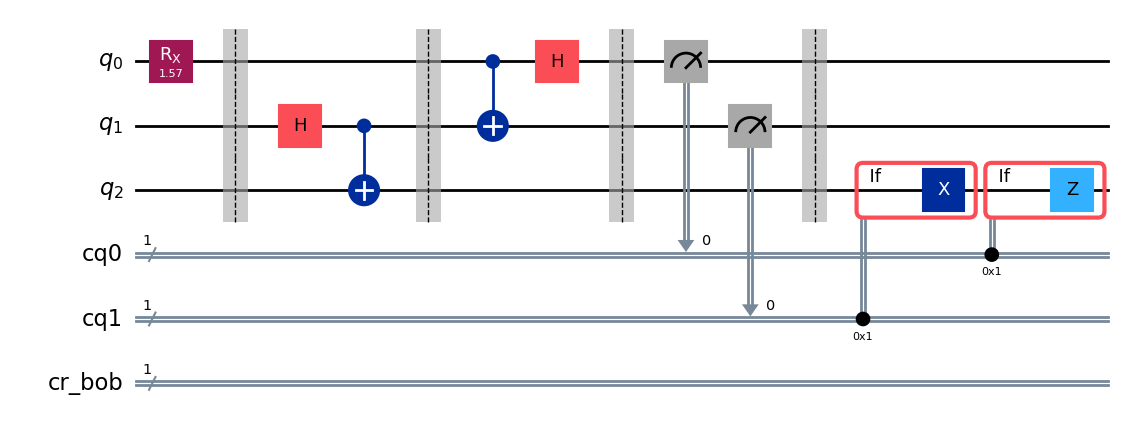

In [60]:
qr = QuantumRegister(3, 'q')      # q0: Message, q1: Alice, q2: Bob
cq0 = ClassicalRegister(1, 'cq0') # Alice's measurement of q0
cq1 = ClassicalRegister(1, 'cq1') # Alice's measurement of q1
cr_bob = ClassicalRegister(1, 'cr_bob') #Bob's measurement of q2

qc = QuantumCircuit(qr, cq0, cq1, cr_bob)

qc.rx(1.57, 0) #introduce a rotation at q0
qc.barrier()

qc.h(1)
qc.cx(1, 2)
qc.barrier()

qc.cx(0,1)
qc.h(0)
qc.barrier()

qc.measure(0, 0)
qc.measure(1, 1)
qc.barrier()

with qc.if_test((cq1, 1)):
    qc.x(2) 

with qc.if_test((cq0, 1)):
    qc.z(2)

qc.draw('mpl')

Measurement Counts (Bob's Bit is the furthest to the left):
{'0 0 1': 251, '0 1 0': 229, '0 0 0': 263, '0 1 1': 257}


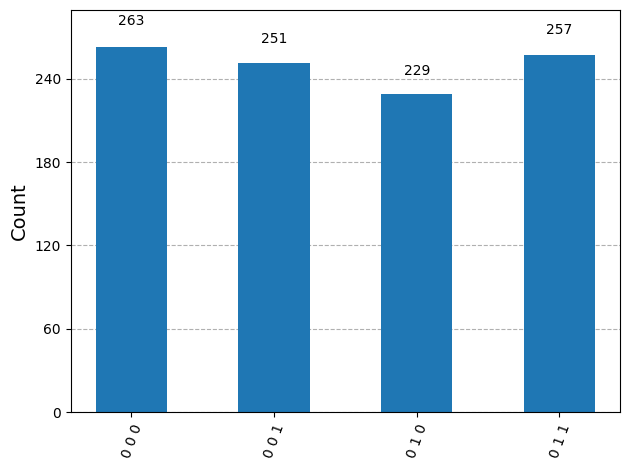

In [55]:
# Apply the inverse of Alice's initial preparation gate to Bob's qubit
qc.rx(-1.57, 2) 

qc.measure(2, cr_bob)

sim = AerSimulator()
job = sim.run(qc, shots=1000)
counts = job.result().get_counts()


print("Measurement Counts (Bob's Bit is the furthest to the left):")
print(counts)
display(plot_histogram(counts))

### We can see in the above histogram that left- most bit(bob's measured bit) is always zero that shows teleportation works  

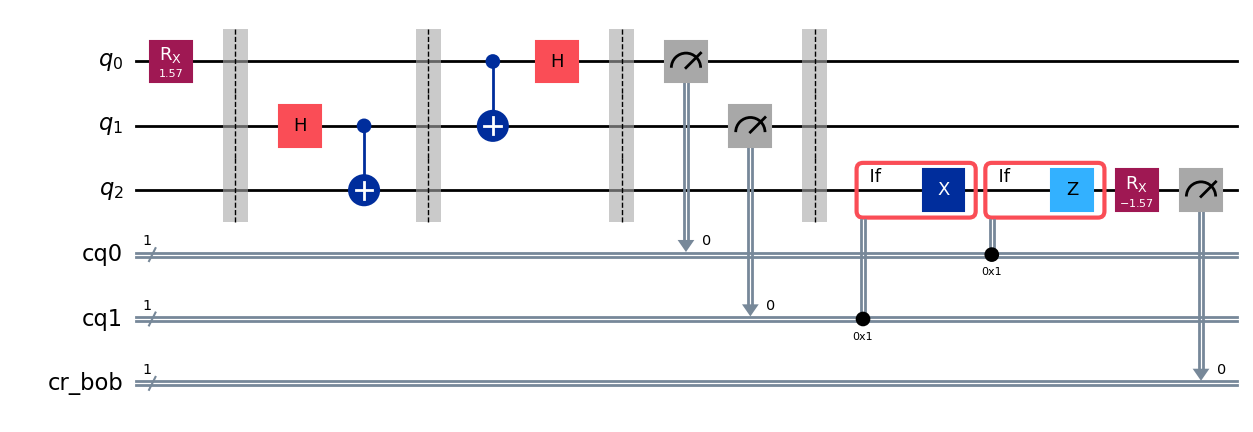

In [56]:
qc.draw('mpl')